# GetProperties

Jupyter notebook interface for the automated collection of molecular descriptors and post-processing (i.e., Boltzmann average, min/max values, etc.) from Gaussian16 log files. Be sure to use the included environment before running.

## Imports

In [1]:
# stdlib
import os
import time
import logging
import itertools

from pathlib import Path
from pprint import pprint
from multiprocessing import Pool

# Data wrangling
import numpy as np
import pandas as pd

# Misc
from rdkit import Chem
from natsort import natsorted
from IPython.display import SVG, display

# Custom
from GetProperties.goodvibes_functions import get_goodvibes_data
from GetProperties.property_functions import get_frontierorbs, get_polarizability, get_dipole, get_volume
from GetProperties.property_functions import get_SASA, get_nbo, get_nmr, get_distance, get_angles, get_dihedral
from GetProperties.property_functions import get_vbur_scan, get_sterimol_morfeus, get_chelpg, get_hirshfeld
from GetProperties.property_functions import get_pyramidalization, get_wall_time, get_plane_angle, get_sterimol_dbstep

from GetProperties.utils import convert_files_in_directory
from GetProperties.utils import _read_in_mol_sdf_with_xyz_correction
from GetProperties.utils import FILE_COLUMN_NAME
from GetProperties.utils import draw_3D_mol
from GetProperties.utils import configure_logger
from GetProperties.utils import split_compound_name
from GetProperties.utils import _get_atom_map, mol_to_image

# Initial settings
pd.options.display.max_columns = None
logger = logging.getLogger('notebook')

[DEBUG - 03/20/2026:12:36:29] [__init__] matplotlib data path: /opt/miniconda3/envs/gpenv_312/lib/python3.12/site-packages/matplotlib/mpl-data
[DEBUG - 03/20/2026:12:36:29] [__init__] CONFIGDIR=/Users/jameshoward/.matplotlib
[DEBUG - 03/20/2026:12:36:29] [__init__] interactive is False
[DEBUG - 03/20/2026:12:36:29] [__init__] platform is darwin
[DEBUG - 03/20/2026:12:36:30] [__init__] CACHEDIR=/Users/jameshoward/.matplotlib
[DEBUG - 03/20/2026:12:36:30] [font_manager] Using fontManager instance from /Users/jameshoward/.matplotlib/fontlist-v390.json


## Settings
In this section, point the Path `data` to the directory containing your G16 log files. The script will automatically convert them to .mol files for further processing.

In [2]:
# Point to path of the log files
data_dir = Path('./data/test_files/')

# Point to path where results and intermediate files are saved
results_dir = Path('./results/')
results_dir.mkdir(exist_ok=True, parents=True)

# Define number of processors to use (set to number or os.cpu_count())
procs = os.cpu_count()

# Turn on debug printing
debug = False

# Format the logging (you don't have to edit this)
configure_logger(debug=debug)

## Convert .log files to .mol files
This section converts the .log files to .mol files. These .mol files can be read in with RDKit for 
downstream processing.

In [3]:
# Convert the logfiles into .mol files for reading in with RDKit
# This function returns the files that failed and will be moved
failed_files = convert_files_in_directory(directory=data_dir)

# Move and log the failed files
if len(failed_files) != 0:
    logger.warning(f'Some files do not have corresponding .mol files')
    for f in failed_files:
        logger.warning(f.name)

mol_files = [x for x in data_dir.glob('*.mol')]

logger.info('There are %d files that do not have a corresponding .mol file.', len(failed_files))
logger.info('There are %d .mol files.', len(mol_files))

[INFO  - 03/20/2026:12:36:30] [utils] Converting 0 logfiles to .mol files.
[INFO  - 03/20/2026:12:36:30] [286859189] There are 0 files that do not have a corresponding .mol file.
[INFO  - 03/20/2026:12:36:30] [286859189] There are 14 .mol files.


## Define substructure for featurization
Provide and [SMARTS](https://www.daylight.com/dayhtml/doc/theory/theory.smarts.html) string or SMILES string that defines the substructure to featurize. If you are unfamiliar with SMARTS patterns, begin by copying the SMILES directly from ChemDraw first. If that does not correspond to your desired substructure (e.g., hydrogens are missing), consult the [SMARTS documentation](https://www.daylight.com/dayhtml/doc/theory/theory.smarts.html). You can visualize your
SMARTS query with the [SMARTS PLUS](https://smarts.plus/) webtool.


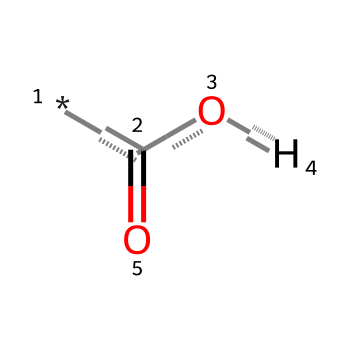

In [4]:
# Define a substructure common to all data files you are looking at
substructure = Chem.MolFromSmarts('[*]C(O[H])=O')

im = mol_to_image(substructure,
                  show_atom_indices=True,
                  image_size=(350, 350))

display(SVG(data=im))

## Generate DataFrame containing files and atom numbers
Here we read in the `.mol` files and identify the substructure pattern in each. These identified patterns will be assigned an atom number (1-indexed values) that we will eventually turn into a text label that is meaningful for parameterization.

In [5]:
# Get the atom maps in parallel
# This returns a list of maps where the first item in the maps is the
# file name and the remaining items are 1-indexed atom numbers
with Pool(processes=procs) as p:
    results = p.starmap(_get_atom_map, zip(natsorted(list(data_dir.glob('*.mol'))), itertools.repeat(substructure)))

failed_files = []
new_results = []

# Iterate through the results
for item in results:
    if len(item) == 1:
        logger.warning('%s is not readable with RDKit or failed substructure matching.', item[0])
        failed_files.append(item[0])
    else:
        new_results.append(item)

# Place the atom numbers for the substructure for each log file into a dataframe
prelim_df = pd.DataFrame(new_results)
prelim_df.rename(columns={0: FILE_COLUMN_NAME, **{i: f'atom_{i}' for i in prelim_df.columns if i != 0}}, inplace=True)


# Save the prelim dataframe
prelim_df.to_csv(results_dir / 'preliminary_df.csv')

# Print the failed items
if len(failed_files) != 0:
    logger.warning('Files that were not read in with RDKit:')
    for f in failed_files:
        logger.warning(f)

logger.info('There are %d files that were not read in.', len(failed_files))
logger.info('There are %d files that successfully read in.', prelim_df.shape[0])
display(prelim_df)

[INFO  - 03/20/2026:12:36:31] [2682658480] There are 0 files that were not read in.
[INFO  - 03/20/2026:12:36:31] [2682658480] There are 14 files that successfully read in.


,file,atom_1,atom_2,atom_3,atom_4,atom_5
0,Ac2_1.log,3,2,1,13,12
1,Ac2_2.log,3,2,1,13,12
2,Ac2_3.log,3,2,1,13,12
3,Ac2_4.log,3,2,1,13,12
4,Ac2_5.log,3,2,1,13,12
5,Ac2_6.log,3,2,1,13,12
6,Ac2_7.log,3,2,1,13,12
7,Ac4_1.log,3,2,1,12,11
8,Ac4_2.log,3,2,1,12,11
9,Ac4_3.log,3,2,1,12,11


## Rename columns to user-interpretable labels

This cell will randomly sample rows in your `prelim_df` and draw the molecules with several atoms replaced with column headers (i.e., the atom numbers from your atom map). These column headers should be reassigned to a user-defined label that is more meaningful for property collection. The dictionary template printed at the end of this cell should look something like `{1: '', 2: '', 3: '', 4: '', 5: ''}`. This can be used in the next cell by remapping the numbers to text labels that are easier to understand.

```python
atom_labels = {'atom_1': 'C4',
               'atom_2': 'C1',
               'atom_3': 'O3',
               'atom_4': 'H5',
               'atom_5': 'O2'}
```

In [6]:
# Define the number of rows to sample
number_to_sample = 2

for i, row in prelim_df.iterrows():

    if i == number_to_sample:
        break

    # Read in the file as mol object
    file = Path(data_dir / row[FILE_COLUMN_NAME]).with_suffix('.mol')
    file, mol = _read_in_mol_sdf_with_xyz_correction(file=file)

    logger.info(file.name)
    draw_3D_mol(mol=mol)

    if mol is None:
        logger.error('Sampled a None mol for %s', file.name)
        continue

# Print out a template dictionary
logger.info('Use this dictionary template to define your named atom map.')
pprint({k: '' for k in prelim_df.columns if k != FILE_COLUMN_NAME})

[INFO  - 03/20/2026:12:36:31] [3637745726] Ac2_1.mol


3Dmol.js failed to load for some reason. Please check your browser console for error messages.

[INFO  - 03/20/2026:12:36:31] [3637745726] Ac2_2.mol


3Dmol.js failed to load for some reason. Please check your browser console for error messages.

[INFO  - 03/20/2026:12:36:31] [3637745726] Use this dictionary template to define your named atom map.
{'atom_1': '', 'atom_2': '', 'atom_3': '', 'atom_4': '', 'atom_5': ''}


## Set an atom label dictionary
Use this cell to assign the mapped atom numbers determined in the previous cell to user-interpretable labels. Ensure that your atom numbers are correct by checking the atom number assigned for a particular molecule to the atom number in a visualization program like PyMOL or Avogadro. Alternatively, use the image in the previous cell to see how the column header corresponds with the atom mapped in your substructure. Numbering of different conformers of the same compound will likely be the same (but may not be for symmetrical substructures groups). Symmetric substructures should be processed in later steps to average descriptors or compute differences.


**NOTE: it is very important you assign these correctly otherwise the properties you collect will be for the wrong atoms.** 

In [7]:
# Create an atom label dictionary
atom_labels = {'atom_1': 'C4',
               'atom_2': 'C1',
               'atom_3': 'O3',
               'atom_4': 'H5',
               'atom_5': 'O2'}

# Rename columns using the user input above
atom_map_df = prelim_df.rename(columns=atom_labels)

# Drop unmapped atoms
unlabeled_columns = [x for x in atom_map_df.columns if 'atom_' in x]
if unlabeled_columns:
    logger.warning('Dropping unlabeled atoms in your mapping. %s', unlabeled_columns)
    atom_map_df.drop(columns=unlabeled_columns, inplace=True)
display(atom_map_df)

# Remove specific atoms if you wish to not collect descriptors for particular atoms
atom_map_df.drop(columns=[], inplace=True)

# df is what properties will be appended to, this creates a copy so that you have the original preserved
df = atom_map_df.copy(deep=True)

all_mapped_atoms = list(atom_labels.values())

# Print a list of all atom labels that can be pasted into the
# functions to collect properties for all mapped atoms
logger.info('List of all mapped atoms in your substructure.')
logger.info(list(atom_labels.values()))

# Save atom map to Excel
atom_map_df.to_csv(results_dir / 'atom_map.csv', index=False)

,file,C4,C1,O3,H5,O2
0,Ac2_1.log,3,2,1,13,12
1,Ac2_2.log,3,2,1,13,12
2,Ac2_3.log,3,2,1,13,12
3,Ac2_4.log,3,2,1,13,12
4,Ac2_5.log,3,2,1,13,12
5,Ac2_6.log,3,2,1,13,12
6,Ac2_7.log,3,2,1,13,12
7,Ac4_1.log,3,2,1,12,11
8,Ac4_2.log,3,2,1,12,11
9,Ac4_3.log,3,2,1,12,11


[INFO  - 03/20/2026:12:36:31] [221707778] List of all mapped atoms in your substructure.
[INFO  - 03/20/2026:12:36:31] [221707778] ['C4', 'C1', 'O3', 'H5', 'O2']


## Define Properties to Collect
This cell contains all of the functions that extract/compute properties from the logfiles. If you do not wish to extract a property, place a pound sign `#` to comment out the function call.

In [8]:
t1 = time.time()
df = atom_map_df.copy()

#---------------GoodVibes Engergies---------------
# Uses the GoodVibes 2021 Branch (Jupyter Notebook Compatible) to compute the quasi
# harmonic corrected G(T) and single point corrected G(T) and other thermodynamic properties
df = get_goodvibes_data(df, data_dir=data_dir, temp=298.15, procs=procs)

#---------------Frontier Orbitals-----------------
# Extracts the E(HOMO), E(LUMO), mu(chemical potential or negative of molecular electronegativity),
# eta(hardness/softness), omega(electrophilicity index)
df = get_frontierorbs(df, data_dir=data_dir, procs=procs)

#---------------Polarizability--------------------
# Extracts the isotropic and anisotropic polarizability
df = get_polarizability(df, data_dir=data_dir, procs=procs)

#---------------Dipole----------------------------
# Extracts the total dipole moment magnitude in Debye
df = get_dipole(df, data_dir=data_dir, procs=procs)

#---------------Volume----------------------------
# Extracts the molar volume
# Requires the Gaussian keyword = "volume" in the .com file
df = get_volume(df, data_dir=data_dir, procs=procs)

#---------------SASA------------------------------
# Uses MORFEUS to compute sovlent accessible surface area (SASA) and the volume under the SASA
df = get_SASA(df, data_dir=data_dir, procs=procs)

#---------------NBO-------------------------------
# Extracts the natural charge from natural population analysis
# Requires the Gaussian keyword = "pop=nbo7" in the .com file
nbo_list = all_mapped_atoms
df = get_nbo(df, atom_list=nbo_list, data_dir=data_dir, procs=procs)

#---------------NMR-------------------------------
# Extracts the isotropic NMR shielding magnitude (inversely related to chemical shift)
# Requires the Gaussian keyword = "nmr=giao" in the .com file
nmr_list = all_mapped_atoms
df = get_nmr(df, atom_list=nmr_list, data_dir=data_dir, procs=procs)

#---------------Dihedral--------------------------
# Computes the dihedral angle between 4 atoms
dihedral_list_of_lists = [['O2', 'C1', 'O3', 'H5']]
df = get_dihedral(df, dihedral_list=dihedral_list_of_lists, data_dir=data_dir, procs=procs)

#---------------Distance--------------------------
# Computes the distance between 2 atoms
dist_list_of_lists = [['O2', 'C1'], ['O3', 'H5'], ['C4', 'C1']]
df = get_distance(df, dist_list=dist_list_of_lists, data_dir=data_dir, procs=procs)

#---------------Angle-----------------------------
# Computes the angle between 3 atoms
angle_list_of_lists = [['O3', 'C1', 'O2'], ['C4', 'C1', 'O3']]
df = get_angles(df, angle_list=angle_list_of_lists, data_dir=data_dir, procs=procs)

#---------------Vbur Scan-------------------------
# Uses MORFEUS to compute the buried volume at a series of radii (including hydrogens)
# If you only want a single radius, put the same value for start_radius and end_radius (keep step_size > 0)
vbur_list = ['C4']
df = get_vbur_scan(df,
                   data_dir=data_dir,
                   a_list=vbur_list,
                   start_r=2,
                   end_r=4,
                   step_size=0.5,
                   procs=procs)

#---------------Pyramidalization------------------
# Uses MORFEUS to calculate pyramidalization of 3 atoms in closest proximity to the defined atom
# and collects two definitions of pyramidalization
# See https://kjelljorner.github.io/morfeus/pyramidalization.html
pyr_list = ['O3']
df = get_pyramidalization(df, atom_list=pyr_list, data_dir=data_dir, procs=procs)

#---------------Sterimol MORFEUS------------------
# Uses MORFEUS to calculate Sterimol L, B1, and B5 values
# This is much faster than using DBSTEP and is recommeded unless you need Sterimol2Vec
sterimol_list_of_lists = [['C1', 'C4']]
df = get_sterimol_morfeus(df, data_dir=data_dir, sterimol_list=sterimol_list_of_lists, radius=None, procs=procs)

#---------------Buried Sterimol-------------------
# Uses MORFEUS to calculate Sterimol L, B1, and B5 values within a sphere
# Atoms outside the sphere + (0.5*vdW_radius) are removed before computing Sterimol
# See https://kjelljorner.github.io/morfeus/sterimol.html
sterimol_list_of_lists = [['C1', 'C4']]
df = get_sterimol_morfeus(df, data_dir=data_dir, sterimol_list=sterimol_list_of_lists, radius=5.5, procs=procs)

#---------------Sterimol DBSTEP-------------------
# Uses DBSTEP to calculate Sterimol L, Bmin, and Bmax values using the
# default grid spacing. This is slower than MORFEUS and not recommended.
#sterimol_list_of_lists = [['C1', 'C4']]
#df = get_sterimol_dbstep(df, data_dir=data_dir, sterimol_list=sterimol_list_of_lists, procs=procs)

#---------------ChelpG----------------------------
# Extracts the ChelpG ESP charge
# Requires the Gaussian keyword = 'pop=chelpg'
#a_list = all_mapped_atoms
#df = get_chelpg(df, atom_list=a_list, data_dir=data_dir, procs=procs)

#---------------Hirshfeld-------------------------
# Extracts the Hirshfeld charge, CM5 charge, Hirshfeld atom dipole
# Requires the Gaussian keyword = 'pop=hirshfeld'
#a_list = all_mapped_atoms
#df = get_hirshfeld(df, atom_list=a_list, data_dir=data_dir, procs=procs)

#---------------Plane Angle-----------------------
# Plane angle between 2 planes (each defined by 3 atoms)
plane_atom_names = [['C4', 'C1', 'O3'], ['C4', 'C1', 'O2']]
df = get_plane_angle(df, plane_atom_names=plane_atom_names, data_dir=data_dir, procs=procs)

#---------------Time------------------------------
# Extracts the wall time in hours for the entire calculation
df = get_wall_time(df, data_dir=data_dir, procs=procs)

# Save the individual properties for record keeping
df.to_csv(results_dir / 'individual_properties.csv', index=False)
logger.info('Property extraction completed in %.2f seconds', time.time() - t1)
display(df)

[WARNING - 03/20/2026:12:36:33] [goodvibes_functions] Defaulting to zpe_fac = 1.0 for B3LYP/6-31G(D,P)
[INFO  - 03/20/2026:12:36:33] [ccio] Identified logfile to be in Gaussian format
[WARNING - 03/20/2026:12:36:33] [goodvibes_functions] Defaulting to zpe_fac = 1.0 for B3LYP/6-31G(D,P)
[INFO  - 03/20/2026:12:36:33] [ccio] Identified logfile to be in Gaussian format
[WARNING - 03/20/2026:12:36:34] [goodvibes_functions] Defaulting to zpe_fac = 1.0 for B3LYP/6-31G(D,P)
[INFO  - 03/20/2026:12:36:34] [ccio] Identified logfile to be in Gaussian format
[WARNING - 03/20/2026:12:36:34] [goodvibes_functions] Defaulting to zpe_fac = 1.0 for B3LYP/6-31G(D,P)
[INFO  - 03/20/2026:12:36:34] [ccio] Identified logfile to be in Gaussian format
[WARNING - 03/20/2026:12:36:34] [goodvibes_functions] Defaulting to zpe_fac = 1.0 for B3LYP/6-31G(D,P)
[INFO  - 03/20/2026:12:36:34] [ccio] Identified logfile to be in Gaussian format
[WARNING - 03/20/2026:12:36:34] [goodvibes_functions] Defaulting to zpe_fac = 1.

,file,C4,C1,O3,H5,O2,E_spc (Hartree),ZPE(Hartree),H_spc(Hartree),T*S,T*qh_S,G(T)_spc(Hartree),qh_G(T)_spc(Hartree),T,HOMO,LUMO,μ,η,ω,polar_iso(au),polar_aniso(au),dipole(Debye),volume(Bohr_radius³/mol),SASA_surface_area(Å²),SASA_volume(Å³),SASA_sphericity,NBO_charge_C4,NBO_charge_C1,NBO_charge_O3,NBO_charge_H5,NBO_charge_O2,NMR_isotropic_shielding_C4,NMR_isotropic_shielding_C1,NMR_isotropic_shielding_O3,NMR_isotropic_shielding_H5,NMR_isotropic_shielding_O2,dihedral_O2_C1_O3_H5 (°),distance_O2_C1(Å),distance_O3_H5(Å),distance_C4_C1(Å),angle_O3_C1_O2(°),angle_C4_C1_O3(°),%Vbur_C4_2.0Å,%Vbur_C4_2.5Å,%Vbur_C4_3.0Å,%Vbur_C4_3.5Å,%Vbur_C4_4.0Å,pyramidalization_Gavrish_O3(°),pyramidalization_Agranat-Radhakrishnan_O3,Sterimol_L_C1_C4(Å)_morfeus,Sterimol_B1_C1_C4(Å)_morfeus,Sterimol_B5_C1_C4(Å)_morfeus,Buried_Sterimol_L_C1_C4_5.0(Å),Buried_Sterimol_B1_C1_C4_5.0(Å),Buried_Sterimol_B5_C1_C4_5.0(Å),plane_angle_C4-C1-O3_C4-C1-O2 (°),wall_time (h)
0,Ac2_1.log,3,2,1,13,12,-630.269945,0.207385,-630.047973,0.056436,0.053883,-630.104409,-630.101857,298.15,-0.33121,0.0297,-0.150755,0.36091,0.03149,104.011,39.8671,0.9884,1576.626,374.966778,549.79263,0.865547,-0.32561,0.78855,-0.67409,0.49852,-0.59935,139.9679,-7.0349,114.0309,25.4803,-148.9527,0.166,1.21181,0.97211,1.51161,123.583906,111.393078,97.281767,82.531905,66.212567,53.226332,41.993436,12.117993,1.998758,8.211378,1.983651,6.865613,5.960138,1.836902,4.56183,0.604,0.107389
1,Ac2_2.log,3,2,1,13,12,-630.269428,0.207811,-630.047195,0.055718,0.053173,-630.102913,-630.100368,298.15,-0.33516,0.03818,-0.14849,0.37334,0.02953,102.95,31.8,1.5172,1399.755,367.537029,546.8334,0.879872,-0.33583,0.77924,-0.68289,0.49664,-0.59066,140.2534,-7.8473,115.9033,25.6348,-156.5086,0.795,1.20899,0.9721,1.52268,123.670723,111.050478,96.868543,82.629574,66.572929,53.459281,42.267705,12.127174,1.994072,5.997975,1.95298,7.851658,4.480356,1.95298,6.837989,0.715,0.087083
2,Ac2_3.log,3,2,1,13,12,-630.267361,0.207749,-630.045137,0.056266,0.053437,-630.101403,-630.098574,298.15,-0.32994,0.03761,-0.146165,0.36755,0.02906,103.134,33.528,3.4242,1658.272,367.537087,546.617277,0.87964,-0.33593,0.77828,-0.68614,0.49891,-0.58884,139.3582,-6.3731,103.0462,25.6652,-149.7877,1.758,1.20913,0.97215,1.52466,123.443504,113.014194,96.629649,82.110301,66.149248,53.223421,42.066756,12.171822,1.986805,6.386459,1.954263,7.716563,4.924588,1.954263,6.904034,0.544,0.086306
3,Ac2_4.log,3,2,1,13,12,-630.267558,0.207938,-630.045318,0.054687,0.052649,-630.100004,-630.097967,298.15,-0.33296,0.03323,-0.149865,0.36619,0.03067,101.697,19.8514,3.4022,1547.041,352.607161,534.121563,0.902859,-0.32821,0.7821,-0.68613,0.49671,-0.58909,138.4756,-7.2824,114.7135,25.6347,-157.4979,0.138,1.20824,0.97208,1.52514,123.504173,110.602004,96.923425,82.601901,66.763819,54.673523,44.751645,12.131823,1.998969,4.450363,1.983582,7.113989,4.211451,1.983582,6.692672,0.144,0.124972
4,Ac2_5.log,3,2,1,13,12,-630.267363,0.207748,-630.045139,0.056267,0.053438,-630.101405,-630.098576,298.15,-0.32995,0.03761,-0.14617,0.36756,0.02906,103.134,33.5292,3.4238,1229.076,367.197077,546.046923,0.879842,-0.33592,0.77828,-0.68612,0.49891,-0.58885,139.3582,-6.3726,103.0557,25.6652,-149.7796,1.759,1.20914,0.97215,1.52467,123.444625,113.015588,96.600594,82.113556,66.148316,53.219926,42.083049,12.171779,1.986803,6.386233,1.954635,7.716488,4.924617,1.954635,6.904094,0.545,0.137028
5,Ac2_6.log,3,2,1,13,12,-630.267815,0.207321,-630.045895,0.055961,0.053757,-630.101856,-630.099652,298.15,-0.3275,0.02678,-0.15036,0.35428,0.03191,103.569,37.4198,3.817,1315.74,371.816743,548.657497,0.871678,-0.31868,0.78849,-0.67549,0.49929,-0.59431,139.0618,-5.8055,115.0018,25.4815,-151.5331,0.026,1.21104,0.97216,1.51264,123.672696,111.262407,97.756327,83.143964,66.801065,54.21578,44.145304,12.118192,1.999809,8.611114,2.466959,4.424492,7.647057,1.904936,4.424492,0.047,0.074667
6,Ac2_7.log,3,2,1,13,12,-630.266133,0.20787,-630.043902,0.054888,0.052778,-630.098789,-630.096679,298.15,-0.33084,0.03289,-0.148975,0.36373,

## Non-parallelized Functions
These properties are less commonly extracted and are not currently parallelized. Their function in the new notebook is not validated as of March 13th, 2026.

In [9]:
#---------------IR--------------------------------
#CAUTION: CANNOT ACCURATELY IDENTIFY ATOM STRETCHES IN MOST CASES (strugges if there is more than one stretch in the defined range)
#IR frequencies and intensities in a specific range (for specific atoms)
#requires the Gaussian keyword = "freq=noraman" in the .com file
#inputs: dataframe, atom1, atom2, frequency_min, frequency_max, intensity_min, intensity_max, threshold
#if you want to collect multiple IR frequencies, you will need to copy/paste this function for each stretch
#we recommend a threshold of 0.0 (may have to adjust)
#df = gp.get_IR(df, "C1", "O2", 1700, 1900, 100, 800, 0.0)

#---------------Sterimol2Vec----------------------
# Sses DBSTEP to calculate Sterimol Bmin and Bmax values at intervals from 0 to end_radius, with a given step_size
# Default grid point spacing (0.05 Angstrom) is used (can use custom spacing or vdw radii in the get_properties_functions script)
#more info here: https://github.com/patonlab/DBSTEP
#inputs: dataframe, list of atom pairs, end_radius, and step_size
#sterimol2vec_list_of_lists = [["C1", "C4"]]
#df = gp.get_sterimol2vec(df, sterimol2vec_list_of_lists, 1, 1.0)

## Save collected properties to Excel
It can be helpful to save the properties of the individual files to read in later if the notebook crashes or if you want to add more properties before post-processsing.

In [10]:
# Save to an excel file, ignore index since it is an arbitrary integer index at this point
df.to_excel(results_dir / 'individual_properties.xlsx', engine='openpyxl', index=False)

## Post-processing
The following cells perform a post-processing in which we compute derivative properties like _min, _max, _boltz, _stddev, and _range.

## Generating a list of compounds that have conformational ensembles

In [11]:
# (Optional) Read in the conformer specific properties. Otherwise, use the df we just created
df = pd.read_excel(results_dir / 'individual_properties.xlsx', header=0, sheet_name='Sheet1')

# Define the character(s) that separates the file name and the conformer number
# e.g., molecule14_5 -> ['molecule14', 5]
separator = '_'

# Drop anything that's not a property we want to average
# Recommended to drop the atom mappings
columns_to_drop = all_mapped_atoms

# Energy column header for boltzmann weighting and lowest energy conformer
energy_col_header = 'G(T)_spc(Hartree)'

# Specify energy cutoff in kcal/mol to remove conformers above this value before post-processing
energy_cutoff = 5.0

# Get prefix (molecule name) and suffix (conformer number) of the compound.
# Then sort the columns
df['PREFIX'] = df[FILE_COLUMN_NAME].apply(split_compound_name, delimiter=separator, return_key=0)
df['SUFFIX'] = df[FILE_COLUMN_NAME].apply(split_compound_name, delimiter=separator, return_key=1)
df = df[[FILE_COLUMN_NAME, 'PREFIX', 'SUFFIX'] + [x for x in df.columns if x not in [FILE_COLUMN_NAME, 'PREFIX', 'SUFFIX']]]
df.sort_values(by=['PREFIX', 'SUFFIX'], inplace=True)

try:
    df.drop(columns=columns_to_drop, inplace=True)
except KeyError as e:
    logger.error('Could not drop %s from DataFrame', columns_to_drop)

display(df)

# Make a dict of compound_id : number_of_conformer
compound_id_conf_number_dict = {}
for compound_name in set(df['PREFIX'].to_list()):
    compound_id_conf_number_dict[compound_name] = len(df[df['PREFIX'] == compound_name])

,file,PREFIX,SUFFIX,E_spc (Hartree),ZPE(Hartree),H_spc(Hartree),T*S,T*qh_S,G(T)_spc(Hartree),qh_G(T)_spc(Hartree),T,HOMO,LUMO,μ,η,ω,polar_iso(au),polar_aniso(au),dipole(Debye),volume(Bohr_radius³/mol),SASA_surface_area(Å²),SASA_volume(Å³),SASA_sphericity,NBO_charge_C4,NBO_charge_C1,NBO_charge_O3,NBO_charge_H5,NBO_charge_O2,NMR_isotropic_shielding_C4,NMR_isotropic_shielding_C1,NMR_isotropic_shielding_O3,NMR_isotropic_shielding_H5,NMR_isotropic_shielding_O2,dihedral_O2_C1_O3_H5 (°),distance_O2_C1(Å),distance_O3_H5(Å),distance_C4_C1(Å),angle_O3_C1_O2(°),angle_C4_C1_O3(°),%Vbur_C4_2.0Å,%Vbur_C4_2.5Å,%Vbur_C4_3.0Å,%Vbur_C4_3.5Å,%Vbur_C4_4.0Å,pyramidalization_Gavrish_O3(°),pyramidalization_Agranat-Radhakrishnan_O3,Sterimol_L_C1_C4(Å)_morfeus,Sterimol_B1_C1_C4(Å)_morfeus,Sterimol_B5_C1_C4(Å)_morfeus,Buried_Sterimol_L_C1_C4_5.0(Å),Buried_Sterimol_B1_C1_C4_5.0(Å),Buried_Sterimol_B5_C1_C4_5.0(Å),plane_angle_C4-C1-O3_C4-C1-O2 (°),wall_time (h)
0,Ac2_1.log,Ac2,1,-630.269945,0.207385,-630.047973,0.056436,0.053883,-630.104409,-630.101857,298.15,-0.33121,0.02970,-0.150755,0.36091,0.03149,104.011,39.8671,0.9884,1576.626,374.966778,549.792630,0.865547,-0.32561,0.78855,-0.67409,0.49852,-0.59935,139.9679,-7.0349,114.0309,25.4803,-148.9527,0.166,1.21181,0.97211,1.51161,123.583906,111.393078,97.281767,82.531905,66.212567,53.226332,41.993436,12.117993,1.998758,8.211378,1.983651,6.865613,5.960138,1.836902,4.561830,0.604,0.107389
1,Ac2_2.log,Ac2,2,-630.269428,0.207811,-630.047195,0.055718,0.053173,-630.102913,-630.100368,298.15,-0.33516,0.03818,-0.148490,0.37334,0.02953,102.950,31.8000,1.5172,1399.755,367.537029,546.833400,0.879872,-0.33583,0.77924,-0.68289,0.49664,-0.59066,140.2534,-7.8473,115.9033,25.6348,-156.5086,0.795,1.20899,0.97210,1.52268,123.670723,111.050478,96.868543,82.629574,66.572929,53.459281,42.267705,12.127174,1.994072,5.997975,1.952980,7.851658,4.480356,1.952980,6.837989,0.715,0.087083
2,Ac2_3.log,Ac2,3,-630.267361,0.207749,-630.045137,0.056266,0.053437,-630.101403,-630.098574,298.15,-0.32994,0.03761,-0.146165,0.36755,0.02906,103.134,33.5280,3.4242,1658.272,367.537087,546.617277,0.879640,-0.33593,0.77828,-0.68614,0.49891,-0.58884,139.3582,-6.3731,103.0462,25.6652,-149.7877,1.758,1.20913,0.97215,1.52466,123.443504,113.014194,96.629649,82.110301,66.149248,53.223421,42.066756,12.171822,1.986805,6.386459,1.954263,7.716563,4.924588,1.954263,6.904034,0.544,0.086306
3,Ac2_4.log,Ac2,4,-630.267558,0.207938,-630.045318,0.054687,0.052649,-630.100004,-630.097967,298.15,-0.33296,0.03323,-0.149865,0.36619,0.03067,101.697,19.8514,3.4022,1547.041,352.607161,534.121563,0.902859,-0.32821,0.78210,-0.68613,0.49671,-0.58909,138.4756,-7.2824,114.7135,25.6347,-157.4979,0.138,1.20824,0.97208,1.52514,123.504173,110.602004,96.923425,82.601901,66.763819,54.673523,44.751645,12.131823,1.998969,4.450363,1.983582,7.113989,4.211451,1.983582,6.692672,0.144,0.124972
4,Ac2_5.log,Ac2,5,-630.267363,0.207748,-630.045139,0.056267,0.053438,-630.101405,-630.098576,298.15,-0.32995,0.03761,-0.146170,0.36756,0.02906,103.134,33.5292,3.4238,1229.076,367.197077,546.046923,0.879842,-0.33592,0.77828,-0.68612,0.49891,-0.58885,139.3582,-6.3726,103.0557,25.6652,-149.7796,1.759,1.20914,0.97215,1.52467,123.444625,113.015588,96.600594,82.113556,66.148316,53.219926,42.083049,12.171779,1.986803,6.386233,1.954635,7.716488,4.924617,1.954635,6.904094,0.545,0.137028
5,Ac2_6.log,Ac2,6,-630.267815,0.207321,-630.045895,0.055961,0.053757,-630.101856,-630.099652,298.15,-0.32750,0.02678,-0.150360,0.35428,0.03191,103.569,37.4198,3.8170,1315.740,371.816743,548.657497,0.871678,-0.31868,0.78849,-0.67549,0.49929,-0.59431,139.0618,-5.8055,115.0018,25.4815,-151.5331,0.026,1.21104,0.97216,1.51264,123.672696,111.262407,97.756327,83.143964,66.801065,54.215780,44.145304,12.118192,1.999809,8.611114,2.466959,4.424492,7.647057,1.904936,4.424492,0.047,0.074667
6,Ac2_7.log,Ac2,7,-630.266133,0.207870,-630.043902,0.054888,0.052778,-630.098789,-630.096679,298.15,-0.33084,0.03289,-0.148975,0.36373,0.03051,101.458,17.2

## Removing columns and rows with missing values

This cell removes columns for which all values are missing. It then removes rows with any missing values.

In [12]:
# Get the columns with all np.nan
missing_value_cols = df.columns[df.isna().all()].tolist()
if missing_value_cols:
    logger.warning('All of the values in some columns were missing\t%s', missing_value_cols)
df.drop(columns=missing_value_cols, inplace=True)

# Drop any row with missing data
to_remove = df[df.isna().any(axis=1)]
to_keep = df[~df.isna().any(axis=1)]

# Display DataFrames
logger.info('There were %d rows removed because of missing values', to_remove.shape[0])
if not to_remove.empty:
    display(to_remove)

# Make a new DataFrame and convert everything but known strings to float
df = to_keep.copy(deep=True)
df[[x for x in df.columns if x not in [FILE_COLUMN_NAME, 'PREFIX', 'SUFFIX', 'file_name', 'file']]] = df[[x for x in df.columns if x not in [FILE_COLUMN_NAME, 'PREFIX', 'SUFFIX', 'file_name']]].astype(float)

logger.info('There are %d rows that remain', to_keep.shape[0])

[INFO  - 03/20/2026:12:37:27] [1231164204] There were 0 rows removed because of missing values
[INFO  - 03/20/2026:12:37:27] [1231164204] There are 14 rows that remain


## Post-processing to get properties for each compound
This cell does the actual weighting. You should change the temperature to reflect the desired temperature of Boltzmann weights. Modify the `min_property_value` variable to change the property with which the XXX_min_conf properties (where XXX is some property like Vbur) are calculated. Set the variable with  `min_property_value = None` to skip computing these properties.

The `ignore_columns` variable is a list of properties that will be skipped when computing summary properties since these properties often do not make sense (e.g., H_spc(Hartree)_Boltz).

In [ ]:
# Set the Boltzmann-weighting temperature
temperature = 298.15

# Set this value to a property name to add properties for the
# conformer with the minimum value of that property (e.g., %Vbur_C4_2.5Å)
# for the "Vbur_min_conf" properties. Set the value to None to skip this.
min_property_value = '%Vbur_C4_2.5Å'

# Define columns that are not processed for summary properties
ignore_columns = [FILE_COLUMN_NAME,
                  energy_col_header,
                  'PREFIX',
                  'SUFFIX',
                  'G(Hartree)',
                  '∆G(Hartree)',
                  '∆G(kcal/mol)',
                  'G(T)_spc(Hartree)',
                  'e^(-∆G/RT)',
                  'Mole Fraction',
                  'wall_time (h)',
                  'E_spc (Hartree)',
                  'H_spc(Hartree)',
                  'T',
                  'T*S',
                  'T*qh_S',
                  'ZPE(Hartree)',
                  'qh_G(T)_spc(Hartree)',
                  ]

ignore_columns.extend(columns_to_drop)

# List of dataframes to concat after everything is done
results = []

# Iterate over all compounds
for compound_identifier, number_of_confs in compound_id_conf_number_dict.items():

    logger.info('Working on %s (nconfs = %d)', compound_identifier, number_of_confs)

    # Read in the PREFIX (which unifies the conformers of a single molecule) as its respective type
    valuesdf = df[df['PREFIX'].astype(str) == str(compound_identifier)].copy(deep=True)

    if len(valuesdf) == 0:
        logger.error('No conformer data was found for %s. Skipping.', compound_identifier)
        continue
    elif len(valuesdf) != number_of_confs:
        raise ValueError(f'Mismatch in number of confs for {compound_identifier}. Should be {number_of_confs} but found {len(valuesdf)}')

    # Check for missing data (likely redundant)
    missing_values_check = valuesdf.copy(deep=True)
    valuesdf.dropna(axis=0, how='any', inplace=True)
    if valuesdf.shape[0] != missing_values_check.shape[0]:
        logger.warning('Some rows in DataFrame had missing properties')

    # Get the columns that we want to min/max/average
    columns_to_process = [x for x in valuesdf.columns if x not in ignore_columns]

    # This section starts the summary properties calculations (Boltz, min, max, etc.)
    # Get the relative energy in Hartrees and kcal
    valuesdf["∆G(Hartree)"] = valuesdf[energy_col_header].astype(float) - valuesdf[energy_col_header].astype(float).min()
    valuesdf["∆G(kcal/mol)"] = valuesdf["∆G(Hartree)"] * 627.509

    # Compute the Boltzmann weights (R is in cal/(K*mol))
    valuesdf["e^(-∆G/RT)"] = (valuesdf["∆G(kcal/mol)"] * -1000) / (1.987204 * temperature)
    valuesdf['e^(-∆G/RT)'] = valuesdf['e^(-∆G/RT)'].astype(float).apply(np.exp)
    valuesdf["Mole Fraction"] = valuesdf["e^(-∆G/RT)"] / valuesdf["e^(-∆G/RT)"].sum()

    # Apply the energy cutoff and reset the arbitrary index
    valuesdf.drop(valuesdf[valuesdf["∆G(kcal/mol)"] >= energy_cutoff].index, inplace=True)
    valuesdf = valuesdf.reset_index(drop=True)

    # Get the LEC and property_minimum_conformer as a DataFrame
    lec_df = valuesdf[valuesdf[energy_col_header].astype(float) == valuesdf[energy_col_header].astype(float).min()].copy()
    if min_property_value is not None:
        prop_min = valuesdf[valuesdf[min_property_value].astype(float) == valuesdf[min_property_value].astype(float).min()].copy()

    # Make a dict for holding summary properties
    summary_properties = {}
    summary_properties[FILE_COLUMN_NAME] = compound_identifier

    # Iterate through the columns that have been filtered down
    for column in columns_to_process:

        # Get min max range
        summary_properties[f'{column}_min'] = valuesdf[column].astype(float).min()
        summary_properties[f'{column}_max'] = valuesdf[column].astype(float).max()
        summary_properties[f'{column}_range'] = valuesdf[column].astype(float).max() - valuesdf[column].astype(float).min()

        # Get boltz
        summary_properties[f'{column}_Boltz'] = (valuesdf[column].astype(float) * valuesdf["Mole Fraction"].astype(float)).sum()

        # Get weighted stdev
        # https://www.statology.org/weighted-standard-deviation-excel/

        if len(valuesdf) == 1:
            summary_properties[f'{column}_Boltz_stdev'] = 0
        else:
            boltz = (valuesdf[column] * valuesdf["Mole Fraction"]).sum()
            delta_values_sq = []

            # Get a list of the weights
            w = valuesdf["Mole Fraction"].astype(float).to_numpy()
            delta_values_sq = valuesdf[column].astype(float).to_numpy()
            delta_values_sq = np.array([(x - boltz)**2 for x in delta_values_sq])

            wstdev = np.sqrt( (np.average(delta_values_sq, weights=w)) / (((len(w) - 1) / len(w)) * np.sum(w)) )
            summary_properties[f'{column}_Boltz_stdev'] = wstdev

        # If there are more than one LECs based on the energy
        if len(lec_df) != 1:

            # Check if all of the values are the same for the property we are looking at
            if not all([x == lec_df[column].astype(float).to_list()[0] for x in lec_df[column].astype(float).to_list()]):
                _lowest_energy_debug = valuesdf[energy_col_header].astype(float).min()
                logger.warning('Multiple LECs of the same energy (%.4f %s) were found.', round(_lowest_energy_debug, 5), energy_col_header)
                logger.warning('These identical energy LECs have different values for %s. Taking the average.', lec_df[column].astype(float).to_list())

            # Take the average either way since it's a low cost operation
            summary_properties[f'{column}_low_E'] = np.average(lec_df[column].astype(float).to_list())
        else:
            # Take the first and only value
            summary_properties[f'{column}_low_E'] = lec_df[column].astype(float).values[0]

        # If there are more than one min_confs based on the property
        if min_property_value is not None:
            if len(prop_min) != 1:

                # Check if all of the values are the same for the property we are looking at
                if not all([x == prop_min[column].astype(float).to_list()[0] for x in prop_min[column].astype(float).to_list()]):
                    _prop_min_debug = valuesdf[prop_min].astype(float).min()
                    logger.warning('Multiple conformers of the same minimum %s (%.4f %s) were found.', prop_min, round(_prop_min_debug, 5), energy_col_header)
                    logger.warning('These identical energy %s have different values for %s. Taking the average.', prop_min, lec_df[column].astype(float).to_list())

                # Take the average either way since it's a low cost operation
                summary_properties[f'{column}_({min_property_value}_min_conf)'] = np.average(lec_df[column].astype(float).to_list())
            else:
                # Take the first and only value
                summary_properties[f'{column}_({min_property_value}_min_conf)'] = lec_df[column].astype(float).values[0]

    results.append(pd.Series(summary_properties))

summary_properties = pd.DataFrame(results)
display(summary_properties)

[INFO  - 03/20/2026:12:38:32] [2230253426] Working on Ac2 (nconfs = 7)
[INFO  - 03/20/2026:12:38:32] [2230253426] Working on Ac5 (nconfs = 3)
[INFO  - 03/20/2026:12:38:32] [2230253426] Working on Ac4 (nconfs = 4)


,file,HOMO_min,HOMO_max,HOMO_range,HOMO_Boltz,HOMO_Boltz_stdev,HOMO_low_E,LUMO_min,LUMO_max,LUMO_range,LUMO_Boltz,LUMO_Boltz_stdev,LUMO_low_E,μ_min,μ_max,μ_range,μ_Boltz,μ_Boltz_stdev,μ_low_E,η_min,η_max,η_range,η_Boltz,η_Boltz_stdev,η_low_E,ω_min,ω_max,ω_range,ω_Boltz,ω_Boltz_stdev,ω_low_E,polar_iso(au)_min,polar_iso(au)_max,polar_iso(au)_range,polar_iso(au)_Boltz,polar_iso(au)_Boltz_stdev,polar_iso(au)_low_E,polar_aniso(au)_min,polar_aniso(au)_max,polar_aniso(au)_range,polar_aniso(au)_Boltz,polar_aniso(au)_Boltz_stdev,polar_aniso(au)_low_E,dipole(Debye)_min,dipole(Debye)_max,dipole(Debye)_range,dipole(Debye)_Boltz,dipole(Debye)_Boltz_stdev,dipole(Debye)_low_E,volume(Bohr_radius³/mol)_min,volume(Bohr_radius³/mol)_max,volume(Bohr_radius³/mol)_range,volume(Bohr_radius³/mol)_Boltz,volume(Bohr_radius³/mol)_Boltz_stdev,volume(Bohr_radius³/mol)_low_E,SASA_surface_area(Å²)_min,SASA_surface_area(Å²)_max,SASA_surface_area(Å²)_range,SASA_surface_area(Å²)_Boltz,SASA_surface_area(Å²)_Boltz_stdev,SASA_surface_area(Å²)_low_E,SASA_volume(Å³)_min,SASA_volume(Å³)_max,SASA_volume(Å³)_range,SASA_volume(Å³)_Boltz,SASA_volume(Å³)_Boltz_stdev,SASA_volume(Å³)_low_E,SASA_sphericity_min,SASA_sphericity_max,SASA_sphericity_range,SASA_sphericity_Boltz,SASA_sphericity_Boltz_stdev,SASA_sphericity_low_E,NBO_charge_C4_min,NBO_charge_C4_max,NBO_charge_C4_range,NBO_charge_C4_Boltz,NBO_charge_C4_Boltz_stdev,NBO_charge_C4_low_E,NBO_charge_C1_min,NBO_charge_C1_max,NBO_charge_C1_range,NBO_charge_C1_Boltz,NBO_charge_C1_Boltz_stdev,NBO_charge_C1_low_E,NBO_charge_O3_min,NBO_charge_O3_max,NBO_charge_O3_range,NBO_charge_O3_Boltz,NBO_charge_O3_Boltz_stdev,NBO_charge_O3_low_E,NBO_charge_H5_min,NBO_charge_H5_max,NBO_charge_H5_range,NBO_charge_H5_Boltz,NBO_charge_H5_Boltz_stdev,NBO_charge_H5_low_E,NBO_charge_O2_min,NBO_charge_O2_max,NBO_charge_O2_range,NBO_charge_O2_Boltz,NBO_charge_O2_Boltz_stdev,NBO_charge_O2_low_E,NMR_isotropic_shielding_C4_min,NMR_isotropic_shielding_C4_max,NMR_isotropic_shielding_C4_range,NMR_isotropic_shielding_C4_Boltz,NMR_isotropic_shielding_C4_Boltz_stdev,NMR_isotropic_shielding_C4_low_E,NMR_isotropic_shielding_C1_min,NMR_isotropic_shielding_C1_max,NMR_isotropic_shielding_C1_range,NMR_isotropic_shielding_C1_Boltz,NMR_isotropic_shielding_C1_Boltz_stdev,NMR_isotropic_shielding_C1_low_E,NMR_isotropic_shielding_O3_min,NMR_isotropic_shielding_O3_max,NMR_isotropic_shielding_O3_range,NMR_isotropic_shielding_O3_Boltz,NMR_isotropic_shielding_O3_Boltz_stdev,NMR_isotropic_shielding_O3_low_E,NMR_isotropic_shielding_H5_min,NMR_isotropic_shielding_H5_max,NMR_isotropic_shielding_H5_range,NMR_isotropic_shielding_H5_Boltz,NMR_isotropic_shielding_H5_Boltz_stdev,NMR_isotropic_shielding_H5_low_E,NMR_isotropic_shielding_O2_min,NMR_isotropic_shielding_O2_max,NMR_isotropic_shielding_O2_range,NMR_isotropic_shielding_O2_Boltz,NMR_isotropic_shielding_O2_Boltz_stdev,NMR_isotropic_shielding_O2_low_E,dihedral_O2_C1_O3_H5 (°)_min,dihedral_O2_C1_O3_H5 (°)_max,dihedral_O2_C1_O3_H5 (°)_range,dihedral_O2_C1_O3_H5 (°)_Boltz,dihedral_O2_C1_O3_H5 (°)_Boltz_stdev,dihedral_O2_C1_O3_H5 (°)_low_E,distance_O2_C1(Å)_min,distance_O2_C1(Å)_max,distance_O2_C1(Å)_range,distance_O2_C1(Å)_Boltz,distance_O2_C1(Å)_Boltz_stdev,distance_O2_C1(Å)_low_E,distance_O3_H5(Å)_min,distance_O3_H5(Å)_max,distance_O3_H5(Å)_range,distance_O3_H5(Å)_Boltz,distance_O3_H5(Å)_Boltz_stdev,distance_O3_H5(Å)_low_E,distance_C4_C1(Å)_min,distance_C4_C1(Å)_max,distance_C4_C1(Å)_range,distance_C4_C1(Å)_Boltz,distance_C4_C1(Å)_Boltz_stdev,distance_C4_C1(Å)_low_E,angle_O3_C1_O2(°)_min,angle_O3_C1_O2(°)_max,angle_O3_C1_O2(°)_range,angle_O3_C1_O2(°)_Boltz,angle_O3_C1_O2(°)_Boltz_stdev,angle_O3_C1_O2(°)_low_E,angle_C4_C1_O3(°)_min,angle_C4_C1_O3(°)_max,angle_C4_C1_O3(°)_range,angle_C4_C1_O3(°)_Boltz,angle_C4_C1_O3(°)_Boltz_stdev,angle_C4_C1_O3(°)_low_E,%Vbur_C4_2.0Å_min,%Vbur_C4_2.0Å_max,%Vbur_C4_2.0Å_range,%Vbur_C4_2.0Å_Boltz,%Vbur_C4_2.0Å_Boltz_stdev,%Vbur_C4_2.0Å_low_E,%Vbur_C4_2.5Å_min,%Vbur_C4_2.5Å_max,%Vbur_C4_2.5Å_rang

## Saving the Results

In [ ]:
summary_properties.to_csv(results_dir / f'summary_properties.csv', index=False)

## Making Derivative Properties
Because some molecules have symmetric substructures that make atom assignment challenging, it can be advantageous to "derivatize" the summary properties. For instance, the two alpha carbons of a ketone may be important for a particular substitution reaction, but it is difficult to assign descriptors to a specific alpha carbon across a series of ketones. 

<img src="./data/figure1.png" style="display:block; margin:auto; width:500px;">

Thus, we can perform mathematical operations on the descriptors to capture substructure symmetry. The alpha carbon descriptors can be further processed to describe the __average__, __min__, or __max__ value of a property across both alpha carbons. Further derivitization like __delta__ could be used to capture the difference in a property between equivalent atoms.

In [ ]:
# Read in the summary properties
df = pd.read_csv(results_dir / f'summary_properties.csv')
display(df)

# TODO Use example files that require symmetrization
raise NotImplementedError

ignore_columns = [FILE_COLUMN_NAME,
                  'PREFIX',
                  'SUFFIX',
                  'G(Hartree)',
                  '∆G(Hartree)',
                  '∆G(kcal/mol)',
                  'e^(-∆G/RT)',
                  'Mole Fraction',
                  'CPU_time_total(hours)',
                  'Wall_time_total(hours)',
                  'E_spc (Hartree)',
                  'H_spc(Hartree)',
                  'T',
                  'T*S',
                  'T*qh_S',
                  'ZPE(Hartree)',
                  'qh_G(T)_spc(Hartree)',
                  ]

# Get a list of descriptors that are candidates for derivative properties
descriptors = [x for x in df.columns if x not in ignore_columns]

# Summary property labels that will be considered
suffixes = ['min', 'max', 'lec', 'boltz']

descriptors_to_symmetrize = [
    # Single atom properties (NBO, ChelpG, Hirsh CM5, Hirsh dipole, NMR)
    ['NBO_charge_S1', 'NBO_charge_S2', 'NBO_charge_S3'],
    ['ChelpG_charge_S1', 'ChelpG_charge_S2', 'ChelpG_charge_S3'],
    ['Hirsh_CM5_charge_S1', 'Hirsh_CM5_charge_S2', 'Hirsh_CM5_charge_S3'],
    ['Hirsh_atom_dipole_S1', 'Hirsh_atom_dipole_S2', 'Hirsh_atom_dipole_S3'],
    ['NMR_shift_S1', 'NMR_shift_S2', 'NMR_shift_S3'],

    # Distances
    ['distance_S1_P(Å)', 'distance_S2_P(Å)', 'distance_S3_P(Å)'],

]

to_drop = []

# For the two chemically equivalent nitrogens
# Find the minimum energy conf properties for N and N'
# Then select the min, max of those two values

#TODO Dont nest loops
for descriptor_group in descriptors_to_symmetrize:

    for s in suffixes:

        # Get all the descriptors with the right suffix
        to_sym = [x for x in descriptors if s in x and any([z in x for z in descriptor_group])]

        if to_sym == []:
            continue

        new_descriptor_base = [x.replace('S1', 'sub') for x in to_sym]
        new_descriptor_base = [x.replace('S2', 'sub') for x in new_descriptor_base]
        new_descriptor_base = [x.replace('S3', 'sub') for x in new_descriptor_base]
        new_descriptor_base = list(set(new_descriptor_base))

        if len(new_descriptor_base) != 1:
            raise ValueError(new_descriptor_base, len(new_descriptor_base))

        new_descriptor_base = new_descriptor_base[0]

        print(f'Going to symmetrize {to_sym}. Base: {new_descriptor_base}')

        df[f'{new_descriptor_base}_min'] = df[to_sym].min(axis=1)
        df[f'{new_descriptor_base}_max'] = df[to_sym].max(axis=1)
        df[f'{new_descriptor_base}_average'] = df[to_sym].mean(axis=1)
        if len(to_sym) == 2:
            df[f'{new_descriptor_base}_delta'] = abs(df[to_sym[0]] - df[to_sym[1]])
        else:
            df[f'{new_descriptor_base}_range'] = abs(df[to_sym].max(axis=1) - df[to_sym].min(axis=1))

        to_drop.extend(to_sym)

df.to_csv('./p_oxide_summary_properties.csv')

